In [13]:
# House Price Prediction - Model Training
# Run 1.EDA.ipynb first to create house_data_cleaned.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)

In [14]:
# Load cleaned data from EDA notebook
data = pd.read_csv('./Data/house_data_cleaned.csv')
print('Shape:', data.shape)
data.head()

Shape: (13258, 4)


,square_footage,bedrooms,bathrooms,price
0,1056.0,2.0,2.0,39.07
1,2600.0,4.0,5.0,120.00
2,1440.0,3.0,2.0,62.00
3,1521.0,3.0,3.0,95.00
4,1200.0,2.0,2.0,51.00


In [15]:
data.describe()

,square_footage,bedrooms,bathrooms,price
count,13258.000000,13258.000000,13258.000000,13258.000000
mean,1558.812282,2.802685,2.688188,112.469985
std,1238.432276,1.292070,1.336751,149.087270
min,1.000000,1.000000,1.000000,8.000000
25%,1100.000000,2.000000,2.000000,50.000000
50%,1275.000000,3.000000,2.000000,72.000000
75%,1680.000000,3.000000,3.000000,120.000000
max,52272.000000,43.000000,40.000000,3600.000000


In [16]:
# Prepare features and target
feature_cols = ['square_footage', 'bedrooms', 'bathrooms']
target_col = 'price'

X = data[feature_cols]
y = data[target_col]

In [17]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 10606
Testing samples:  2652


In [18]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05,-8.46,38.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['square_footage','bedrooms','bathrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-48.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [19]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [20]:
# Model coefficients
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_
})

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: -48.3163


,feature,coefficient
0,square_footage,0.052070
1,bedrooms,-8.456080
2,bathrooms,38.246149


In [21]:
# Evaluate model performance
def evaluate_model(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'--- {label} ---')
    print(f'MSE:  {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAE:  {mae:.2f}')
    print(f'R2:   {r2:.4f}')
    print()

    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

train_metrics = evaluate_model(y_train, y_train_pred, 'Training Set')
test_metrics = evaluate_model(y_test, y_test_pred, 'Testing Set')

--- Training Set ---
MSE:  14140.44
RMSE: 118.91
MAE:  46.39
R2:   0.3697

--- Testing Set ---
MSE:  10938.45
RMSE: 104.59
MAE:  44.67
R2:   0.4884



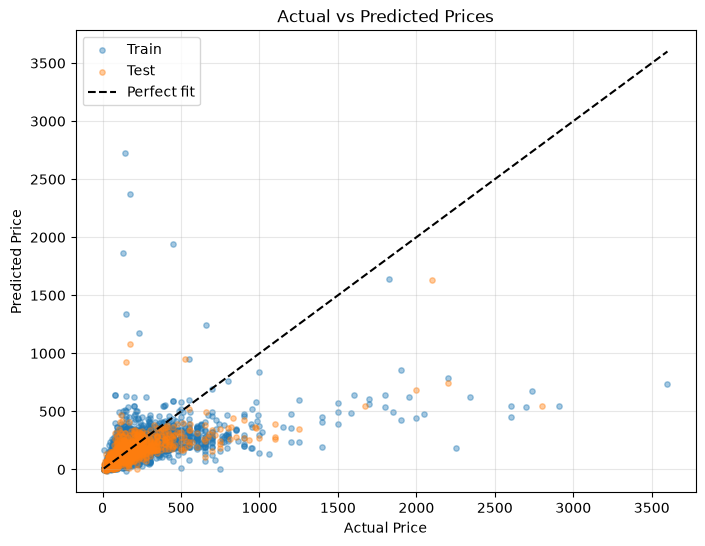

In [22]:
# Actual vs predicted prices
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_train, y_train_pred, alpha=0.4, s=15, label='Train')
ax.scatter(y_test, y_test_pred, alpha=0.4, s=15, label='Test')

line = [y.min(), y.max()]
ax.plot(line, line, 'k--', linewidth=1.5, label='Perfect fit')

ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Actual vs Predicted Prices')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

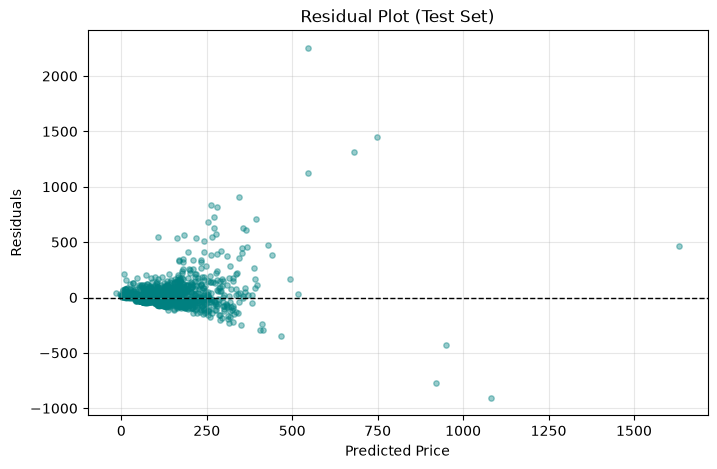

In [23]:
# Residual plot on test set
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4, s=15, color='teal')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot (Test Set)')
plt.grid(alpha=0.3)
plt.show()

In [24]:
# Final summary
print(f"Test R2: {test_metrics['r2']:.2%}")
print(f"Average error on test set: +/- {test_metrics['mae']:.2f} lakhs")

Test R2: 48.84%
Average error on test set: +/- 44.67 lakhs
